In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from MyLib import GPSConverter, es_calc
from scipy.io.netcdf import netcdf_file
from scipy.interpolate import griddata
from osgeo import gdal
import matplotlib.path as mplPath
import glob
from netCDF4 import Dataset # pylint: disable=no-name-in-module
import imageio
import cmocean
import tarfile
from scipy.io import netcdf
from xmitgcm import open_mdsdataset as mitgcmds
import os
from os.path import join
from datetime import datetime, timezone
from matplotlib.dates import date2num, num2date
from shapely.geometry import mapping, Polygon

coord_conv = GPSConverter()

In [2]:
def get_S3_grid(S3_file):
    #%Extract geographical data from the first COSMO-2 file
    #date = datevec(dateini); %Date vector
    #FileName = [datapath sprintf('%i',date(1)) '\cosmo2_epfl_lakes_' sprintf('%i%02i%02i',date(1:3)) '.nc'];
    f = Dataset(S3_file, 'r')
    # Must transpose arrays to be consistent with Fortran ordering
    lon = f.variables["lon"][:].copy()
    lat = f.variables["lat"][:].copy()
    lat_arr,lon_arr = np.meshgrid(lat,lon)
    lat_arr = lat_arr.T
    lon_arr =  lon_arr.T
    f.close()
    converter = GPSConverter()
    x = np.zeros_like(lat_arr)
    y = np.zeros_like(lon_arr)
    
    for jj in range(x.shape[1]):
        for ii in range(x.shape[0]):
            x[ii,jj], y[ii,jj], _ = converter.WGS84toLV03(lat_arr[ii, jj], lon_arr[ii,jj], 0.0)
    return x, y

In [3]:
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path


class SelectFromCollection(object):
    """Select indices from a matplotlib collection using `PolygonSelector`.

    Selected indices are saved in the `ind` attribute. This tool fades out the
    points that are not part of the selection (i.e., reduces their alpha
    values). If your collection has alpha < 1, this tool will permanently
    alter the alpha values.

    Note that this tool selects collection objects based on their *origins*
    (i.e., `offsets`).

    Parameters
    ----------
    ax : :class:`~matplotlib.axes.Axes`
        Axes to interact with.

    collection : :class:`matplotlib.collections.Collection` subclass
        Collection you want to select from.

    alpha_other : 0 <= float <= 1
        To highlight a selection, this tool sets all selected points to an
        alpha value of 1 and non-selected points to `alpha_other`.
    """

    def __init__(self, ax, collection, alpha_other=0.3):
        self.canvas = ax.figure.canvas
        self.collection = collection
        self.alpha_other = alpha_other

        self.xys = collection.get_offsets()
        self.Npts = len(self.xys)

        # Ensure that we have separate colors for each object
        self.fc = collection.get_facecolors()
        if len(self.fc) == 0:
            raise ValueError('Collection must have a facecolor')
        elif len(self.fc) == 1:
            self.fc = np.tile(self.fc, (self.Npts, 1))

        self.poly = PolygonSelector(ax, self.onselect)
        self.ind = []

    def onselect(self, verts):
        path = Path(verts)
        self.ind = np.nonzero(path.contains_points(self.xys))[0]
        self.fc[:, -1] = self.alpha_other
        self.fc[self.ind, -1] = 1
        self.collection.set_facecolors(self.fc)
        self.canvas.draw_idle()

    def disconnect(self):
        self.poly.disconnect_events()
        self.fc[:, -1] = 1
        self.collection.set_facecolors(self.fc)
        self.canvas.draw_idle()


# if __name__ == '__main__':
#     import matplotlib.pyplot as plt

#     fig, ax = plt.subplots()
#     grid_size = 5
#     grid_x = np.tile(np.arange(grid_size), grid_size)
#     grid_y = np.repeat(np.arange(grid_size), grid_size)
#     pts = ax.scatter(grid_x, grid_y)

#     selector = SelectFromCollection(ax, pts)

#     print("Select points in the figure by enclosing them within a polygon.")
#     print("Press the 'esc' key to start a new polygon.")
#     print("Try holding the 'shift' key to move all of the vertices.")
#     print("Try holding the 'ctrl' key to move a single vertex.")

#     plt.show()

#     selector.disconnect()

#     # After figure is closed print the coordinates of the selected points
#     print('\nSelected points:')
#     print(selector.xys[selector.ind])

In [4]:
import random
import shapely
from shapely.geometry import Point, Polygon,LinearRing


def random_points_within(poly, num_points):
    min_x, min_y, max_x, max_y = poly.bounds

    points = []

    while len(points) < num_points:
        random_point = Point([random.uniform(min_x, max_x), random.uniform(min_y, max_y)])
        if (random_point.within(poly)):
            points.append(random_point)

    return points

# S3 to surface particles distribution

In [5]:
data_path = 'G:/ALPLakes/Data/S3/oc3_test_geneva_2021-08-31_2021-09-15/L2POLY/'

solnFolders = sorted(glob.glob(f'{data_path}*.nc'))
# solnFolders = sorted(glob.glob(f'{data_path}L2POLY/*.nc'))

filenames = [os.path.basename(ii) for ii in solnFolders]
try:
    ind_sat = filenames[0].split('_').index('S3A')
except:
    ind_sat = filenames[0].split('_').index('S3B')
    
sat_name = [ii.split('_')[ind_sat] for ii in filenames]
date_time = [datetime.strptime(ii.split('_')[ind_sat+7], '%Y%m%dT%H%M%S') for ii in filenames]

df_s3 = pd.DataFrame(index=date_time,columns=['filename','sat_name'])
df_s3['sat_name'] = sat_name
df_s3['filename'] = filenames
df_s3 = df_s3.sort_index()

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:48: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:65: UserWarning: FixedFormatter should only be used together with FixedLocator


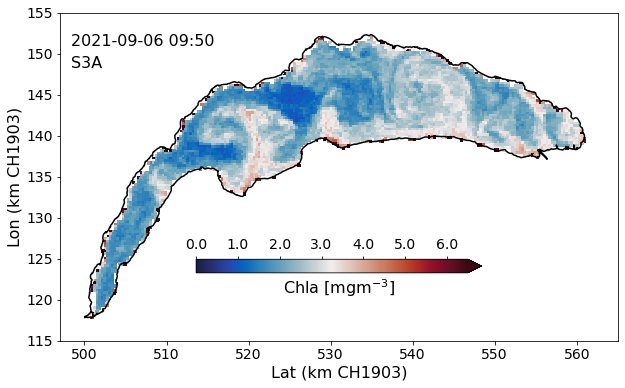

In [6]:
%matplotlib inline

cmap_plt = cmocean.cm.balance #cmocean.cm.delta #cmocean.cm.balance #'twilight_shifted' #cmocean.cm.haline #cmocean.cm.delta
# color_map = plt.cm.get_cmap('seismic') #rainbow
# cmap_plt = color_map.reversed()
data_lim = [0,6.5]
cbar_label = '$\mathregular{Chla \ [mgm^{-3}]}$' #'$\mathregular{Chla \ [mgm^{-3}]}$'
col_name = 'tsm_binding754'

#########
ii = 0
soln = data_path+df_s3['filename'][ii]
variablesFile = Dataset(soln)

xx_sg,yy_sg = get_S3_grid(soln)
xx_sg *= 1.e-3
yy_sg *= 1.e-3

xs, ys = np.genfromtxt("E:/ALPLakes/algal_bloom_Sep2021/Codes/geometery/shoreline_Leman.ldb",unpack=True)
xs *= 1.e-3
ys *= 1.e-3

poly_path=Path([(xs[ii],ys[ii]) for ii in range(len(xs))])
coors=np.hstack((xx_sg.reshape(-1, 1), yy_sg.reshape(-1,1)))
mask = poly_path.contains_points(coors).reshape(xx_sg.shape)


#################
for ii in range(8,9):
    soln = data_path+df_s3['filename'][ii]
    variablesFile = Dataset(soln)
    data = variablesFile.variables[col_name][:]
    data[data <= 0] = np.nan
    
#     # only uncomment to plot total scores
#     data2 = variablesFile.variables['chla'][:]
#     data[np.isnan(data2)] = np.nan

    ##########

    fig_size = (10,5)
    font_feature = ['sans-serif', 16, 14] # [fontname, fontsize_labels, fontsize_ticks]

    f = plt.figure(figsize=fig_size)

    ax = f.add_subplot(111)
    # SS = plt.pcolormesh(xx_sg,yy_sg,Temp, cmap=cmocean.cm.thermal,shading='flat')
    SS = plt.pcolormesh(xx_sg,yy_sg,np.ma.array(data,mask=~mask,fill_value=np.nan),vmin=data_lim[0],vmax=data_lim[1],cmap=cmap_plt,shading='flat') 
    plt.hold=True
    ax.plot(xs,ys, 'k-', lw=1.5)

    plt.xticks(fontname=font_feature[0],fontsize=font_feature[2])
    plt.yticks(fontname=font_feature[0],fontsize=font_feature[2])

    ax.set_xlim(497, 565)
    ax.set_ylim(115, 155)
    ax.set_aspect('equal')
    ax.set_xlabel("Lat (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
    ax.set_ylabel("Lon (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
    ax.annotate(df_s3.index[ii].strftime("%Y-%m-%d %H:%M"),xy=(0.02, 0.9), xycoords='axes fraction',fontname=font_feature[0],fontsize=font_feature[1])
    ax.annotate(df_s3['sat_name'][ii],xy=(0.02, 0.83), xycoords='axes fraction',fontname=font_feature[0],fontsize=font_feature[1])


    cbar = plt.colorbar(fraction=0.05,orientation="horizontal",pad=-0.3,extend='max',format='%:.0f');
    cbar.ax.set_xticklabels(np.around(cbar.ax.get_xticks(), decimals=2),fontname=font_feature[0],fontsize=font_feature[2])
    cbar.set_label(label=cbar_label,family=font_feature[0],size=font_feature[1])
    cbar.ax.xaxis.set_ticks_position('top')

    # plt.savefig(output_path+df_s3.index[ii].strftime("%Y-%m-%d")+'H'+df_s3.index[ii].strftime("%H")+'M'+df_s3.index[ii].strftime("%M")+'_'+df_s3['sat_name'][ii]+'_'+col_name+'.png',dpi=300, bbox_inches = 'tight')

    plt.show()
    plt.close()

In [7]:
xx_sg.shape

(185, 249)

In [8]:
qq=8
soln = data_path+df_s3['filename'][qq]
variablesFile = Dataset(soln)
data = variablesFile.variables[col_name][:]
data[data <= 0] = np.nan

tsm_arr_raw = np.ma.array(data,mask=~mask,fill_value=np.nan).data
tsm_arr_raw[tsm_arr_raw<0] = 0
max_val = np.nanquantile(tsm_arr_raw.flatten(),0.98)


In [9]:
np.nanquantile(tsm_arr_raw.flatten(),0.6)

2.5309605598449707

In [10]:
qq=8
soln = data_path+df_s3['filename'][qq]
variablesFile = Dataset(soln)
data = variablesFile.variables[col_name][:]
data[data <= 0] = np.nan

tsm_arr_raw = np.ma.array(data,mask=~mask,fill_value=np.nan).data
tsm_arr_raw[tsm_arr_raw<0] = 0
max_val = np.nanquantile(tsm_arr_raw.flatten(),0.9)
min_val =np.nanquantile(tsm_arr_raw.flatten(),0.6)
tsm_arr_raw[tsm_arr_raw>max_val] = max_val
tsm_arr_raw[tsm_arr_raw<min_val] = 0
tsm_arr_raw[np.isnan(tsm_arr_raw)] = 0

##############################
polyPoints = []
for ii in range(len(xs)):
    # Add points to polyPoints
    polyPoints.append([xs[ii], ys[ii]])
    
polygon_gva = Polygon(polyPoints)
polygon_gva_expd = polygon_gva.buffer(-0.25, cap_style=1, join_style=2, mitre_limit=1.5)
for ii in range(xx_sg.shape[0]):
    for jj in range(xx_sg.shape[1]):
        if ((Point([xx_sg[ii,jj],yy_sg[ii,jj]]).within(polygon_gva_expd))):
            tsm_arr_raw[ii,jj] = tsm_arr_raw[ii,jj]
        else:
            tsm_arr_raw[ii,jj] = 0


In [11]:
# afpoly = Polygon(polyPoints)

# # Create offset airfoils, both inward and outward
# # poffafpoly = afpoly.buffer(0.03)  # Outward offset
# noffafpoly = afpoly.buffer(-0.25, cap_style=1, join_style=2, mitre_limit=1.5)  # Inward offset

# # Turn polygon points into numpy arrays for plotting
# afpolypts = np.array(afpoly.exterior)
# poffafpolypts = np.array(poffafpoly.exterior)
# noffafpolypts = np.array(noffafpoly.exterior)

# # Plot points
# plt.plot(*afpolypts.T, color='black')
# # plt.plot(*poffafpolypts.T, color='red')
# plt.plot(*noffafpolypts.T, color='green')
# plt.axis('equal')
# plt.show()


In [12]:
n_part = 10000
part_conc = tsm_arr_raw.copy()
part_conc = np.round(n_part*part_conc/np.sum(part_conc)).astype(int)

In [13]:
points_pt = []
for ii in range(1,xx_sg.shape[0]-1):
    for jj in range(1,xx_sg.shape[1]-1):
        if (part_conc[ii,jj]>0):
            points_pt0 = random_points_within(Polygon([[0.5*(xx_sg[ii,jj]+xx_sg[ii-1,jj]),0.5*(yy_sg[ii,jj]+yy_sg[ii,jj-1])],[0.5*(xx_sg[ii,jj]+xx_sg[ii-1,jj]),0.5*(yy_sg[ii,jj]+yy_sg[ii,jj+1])]
                                                       ,[0.5*(xx_sg[ii,jj]+xx_sg[ii+1,jj]),0.5*(yy_sg[ii,jj]+yy_sg[ii,jj+1])],[0.5*(xx_sg[ii,jj]+xx_sg[ii+1,jj]),0.5*(yy_sg[ii,jj]+yy_sg[ii,jj-1])]]), part_conc[ii,jj])
            points_pt.extend(points_pt0)

In [14]:
coords = np.array([p.coords for p in points_pt]).reshape(-1, 2)

# convert to MITgcm grid

In [15]:
(X0, Y0) = (500000, 116500)
(X1, Y1) = (563000, 138700)
gridAngle = np.arctan2(Y1-Y0, X1-X0)

xs_com = np.cos(gridAngle)*(coords[:,0]*1e3-X0) + np.sin(gridAngle)*(coords[:,1]*1e3-Y0)
ys_com = -np.sin(gridAngle)*(coords[:,0]*1e3-X0) + np.cos(gridAngle)*(coords[:,1]*1e3-Y0)

In [16]:
xx_seed = np.tile(xs_com, 3)
yy_seed = np.tile(ys_com, 3)
zz_seed = np.repeat([1,3,5], xs_com.shape)

# output_path = 'G:/ALPLakes/algal_bloom_Sep2021/Particle_tracking/PT6_forward_map/'
# np.savez(output_path+'PT6_30000_3depths.npz', x_seed = xx_seed, y_seed = yy_seed, z_seed = zz_seed)

In [17]:
# np.where(coords[:,1] % 50==0)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:11: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  # This is added back by InteractiveShellApp.init_path()
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator


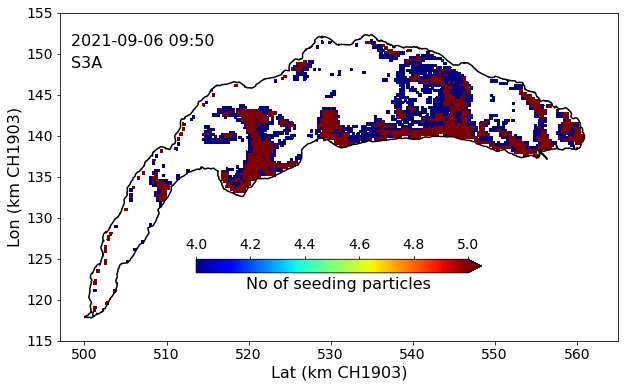

In [18]:
 ##########
part_conc =part_conc.astype(float)     
part_conc[part_conc==0] = np.nan
fig_size = (10,5)
font_feature = ['sans-serif', 16, 14] # [fontname, fontsize_labels, fontsize_ticks]

f = plt.figure(figsize=fig_size)

ax = f.add_subplot(111)
# SS = plt.pcolormesh(xx_sg,yy_sg,Temp, cmap=cmocean.cm.thermal,shading='flat')
SS = plt.pcolormesh(xx_sg,yy_sg,part_conc,cmap='jet',shading='flat') 
plt.hold=True
ax.plot(xs,ys, 'k-', lw=1.5)

plt.xticks(fontname=font_feature[0],fontsize=font_feature[2])
plt.yticks(fontname=font_feature[0],fontsize=font_feature[2])
# plt.plot(coords[:,0],coords[:,1], 'w.')

ax.set_xlim(497, 565)
ax.set_ylim(115, 155)
ax.set_aspect('equal')
ax.set_xlabel("Lat (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
ax.set_ylabel("Lon (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
ax.annotate(df_s3.index[qq].strftime("%Y-%m-%d %H:%M"),xy=(0.02, 0.9), xycoords='axes fraction',fontname=font_feature[0],fontsize=font_feature[1])
ax.annotate(df_s3['sat_name'][qq],xy=(0.02, 0.83), xycoords='axes fraction',fontname=font_feature[0],fontsize=font_feature[1])


cbar = plt.colorbar(fraction=0.05,orientation="horizontal",pad=-0.3,extend='max',format='%:.0f');
cbar.ax.set_xticklabels(np.around(cbar.ax.get_xticks(), decimals=2),fontname=font_feature[0],fontsize=font_feature[2])
cbar.set_label(label='No of seeding particles',family=font_feature[0],size=font_feature[1])
cbar.ax.xaxis.set_ticks_position('top')

# plt.savefig(output_path+'part_seeding_2.png',dpi=300, bbox_inches = 'tight')

plt.show()
plt.close()

In [25]:
#  ##########

# fig_size = (10,5)
# font_feature = ['sans-serif', 16, 14] # [fontname, fontsize_labels, fontsize_ticks]

# f = plt.figure(figsize=fig_size)

# ax = f.add_subplot(111)
# # SS = plt.pcolormesh(xx_sg,yy_sg,Temp, cmap=cmocean.cm.thermal,shading='flat')
# SS = plt.pcolormesh(xx_sg,yy_sg,tsm_arr_raw,vmin=data_lim[0],vmax=data_lim[1],cmap=cmap_plt,shading='flat') 
# plt.hold=True
# ax.plot(xs,ys, 'k-', lw=1.5)

# plt.xticks(fontname=font_feature[0],fontsize=font_feature[2])
# plt.yticks(fontname=font_feature[0],fontsize=font_feature[2])

# ax.set_xlim(497, 565)
# ax.set_ylim(115, 155)
# ax.set_aspect('equal')
# ax.set_xlabel("Lat (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
# ax.set_ylabel("Lon (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
# ax.annotate(df_s3.index[qq].strftime("%Y-%m-%d %H:%M"),xy=(0.02, 0.9), xycoords='axes fraction',fontname=font_feature[0],fontsize=font_feature[1])
# ax.annotate(df_s3['sat_name'][qq],xy=(0.02, 0.83), xycoords='axes fraction',fontname=font_feature[0],fontsize=font_feature[1])


# cbar = plt.colorbar(fraction=0.05,orientation="horizontal",pad=-0.3,extend='max',format='%:.0f');
# cbar.ax.set_xticklabels(np.around(cbar.ax.get_xticks(), decimals=2),fontname=font_feature[0],fontsize=font_feature[2])
# cbar.set_label(label=cbar_label,family=font_feature[0],size=font_feature[1])
# cbar.ax.xaxis.set_ticks_position('top')

# # plt.savefig(output_path+df_s3.index[ii].strftime("%Y-%m-%d")+'H'+df_s3.index[ii].strftime("%H")+'M'+df_s3.index[ii].strftime("%M")+'_'+df_s3['sat_name'][ii]+'_'+col_name+'.png',dpi=300, bbox_inches = 'tight')

# plt.show()
# plt.close()

# small area release points

In [5]:
gcm_directory = 'G:/ALPLakes/MITgcm/grid50_secchi_updated_low/results_5thpart'

# mitgcm output filename root
gcm_out_root = "3Dsnaps"

# reference date of MITgcm simulation
gcm_start = "2021-07-26 00:00"

# MITgcm time step in seconds
gcm_dt = 4.0

# grid geometry used in the MITgcm simulation
gcm_geometry = "cartesian"

In [6]:
# First, we read the grid only
grid = mitgcmds(gcm_directory, delta_t=gcm_dt, ref_date=gcm_start,
                 geometry=gcm_geometry, read_grid=True,
                 prefix=[gcm_out_root], iters=[], swap_dims=False,endian='=')

data = mitgcmds(gcm_directory, delta_t=gcm_dt, ref_date=gcm_start,
                 geometry=gcm_geometry, read_grid=False,
                 prefix=[gcm_out_root],endian='=')

date_obs = data.time.to_masked_array().filled().astype("datetime64[m]")

In [7]:
x_com = np.array(grid.XG[0, :])
y_com = np.array(grid.YG[:, 0])

xx_com,yy_com = np.meshgrid(x_com,y_com)
# (X0, Y0) = (500000, 116500)
# (X1, Y1) = (563000, 138700)
# gridAngle = np.arctan2(Y1-Y0, X1-X0)
# xx_sg = (np.cos(gridAngle)*xx_com - np.sin(gridAngle)*yy_com) + X0
# yy_sg = (np.sin(gridAngle)*xx_com + np.cos(gridAngle)*yy_com) + Y0

# xx_sg *= 1.e-3
# yy_sg *= 1.e-3


# xs, ys = np.genfromtxt("E:/ALPLakes/algal_bloom_Sep2021/Codes/geometery/shoreline_Leman.ldb",unpack=True)
# xs *= 1.e-3
# ys *= 1.e-3

In [4]:
output_path = 'G:/ALPLakes/algal_bloom_Sep2021/Particle_tracking/PT_secchi_low/PT13_forward_south/'

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:19: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


Select points in the figure by enclosing them within a polygon.
Press the 'esc' key to start a new polygon.
Try holding the 'shift' key to move all of the vertices.
Try holding the 'ctrl' key to move a single vertex.


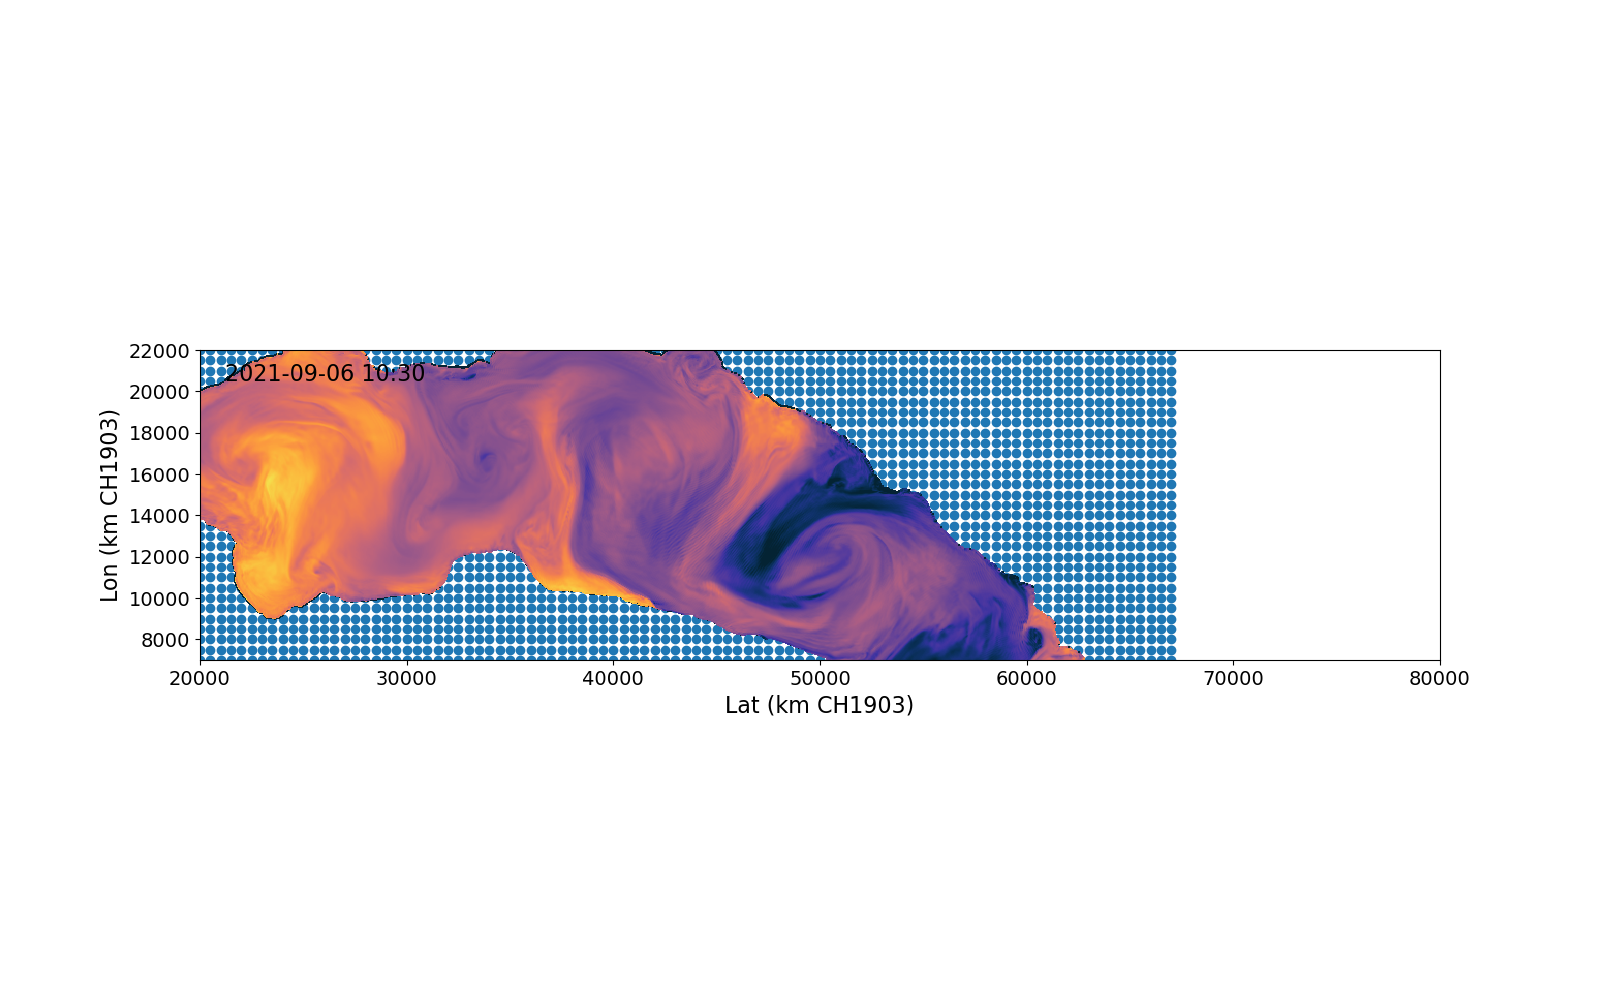

In [90]:
%matplotlib widget
font_feature = ['sans-serif', 16, 14] # [fontname, fontsize_labels, fontsize_ticks]

i=246
Temp = np.array(data.THETA[i, 0:3, :,:].mean(axis=0))
Temp[Temp <= 0] = np.nan
# vort = np.array(data.momVort3[i, 0:1, :,:].mean(axis=0))
# vort /= 1.05e-4

#####################
fig_size = (16,10)


f = plt.figure(figsize=fig_size)

ax = f.add_subplot(111)
# SS = plt.pcolormesh(xx_sg,yy_sg,Temp, cmap=cmocean.cm.thermal,shading='flat')
pts = ax.scatter(xx_com[::10,::10], yy_com[::10,::10])
SS1 = plt.pcolormesh(xx_com,yy_com,Temp, cmap=cmocean.cm.thermal,vmin=np.nanpercentile(Temp.flatten(),2), vmax=np.nanpercentile(Temp.flatten(),98),shading='flat')
# SS2 = plt.pcolormesh(xx_com,yy_com,vort, vmin=-1.2, vmax=1.2,cmap=cmocean.cm.balance,shading='flat')

plt.hold=True
# ax.plot(xs,ys, 'k-', lw=1.5)

plt.xticks(fontname=font_feature[0],fontsize=font_feature[2])
plt.yticks(fontname=font_feature[0],fontsize=font_feature[2])

# ax.set_xlim(39000, 55000)
# ax.set_ylim(2000, 22000)
ax.set_xlim(20000, 80000)
ax.set_ylim(7000, 22000)
# ax.set_xlim(17500, 33000)
# ax.set_ylim(6000, 22000)
# ax.set_xlim(45000, 60000)
# ax.set_ylim(0, 15000)
# ax.set_xlim(57000, 61000)
# ax.set_ylim(1000, 3500)
# ax.set_xlim(10000, 17500)
# ax.set_ylim(10000, 17500)

ax.set_aspect('equal')
ax.set_xlabel("Lat (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
ax.set_ylabel("Lon (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
ax.annotate(date_obs[i].item().strftime("%Y-%m-%d %H:%M"),xy=(0.02, 0.9), xycoords='axes fraction',fontname=font_feature[0],fontsize=font_feature[1])


# cbar = plt.colorbar(fraction=0.04,orientation="horizontal",pad=-0.25,extend='max',format='%:.0f');
# cbar.ax.set_xticklabels(np.around(cbar.ax.get_xticks(), decimals=2),fontname=font_feature[0],fontsize=font_feature[2])
# cbar.set_label(label='$\mathregular{Surface \ temperature \ [^{o}C]}$',family=font_feature[0],size=font_feature[1])
# cbar.ax.xaxis.set_ticks_position('top')

# plt.savefig(output_path+date_obs[i].item().strftime("%Y-%m-%d")+'H'+date_obs[i].item().strftime("%H")+'M'+date_obs[i].item().strftime("%M")+'_Surftemp_vort_2_98perc.png',dpi=300, bbox_inches = 'tight')

selector = SelectFromCollection(ax, pts)

print("Select points in the figure by enclosing them within a polygon.")
print("Press the 'esc' key to start a new polygon.")
print("Try holding the 'shift' key to move all of the vertices.")
print("Try holding the 'ctrl' key to move a single vertex.")


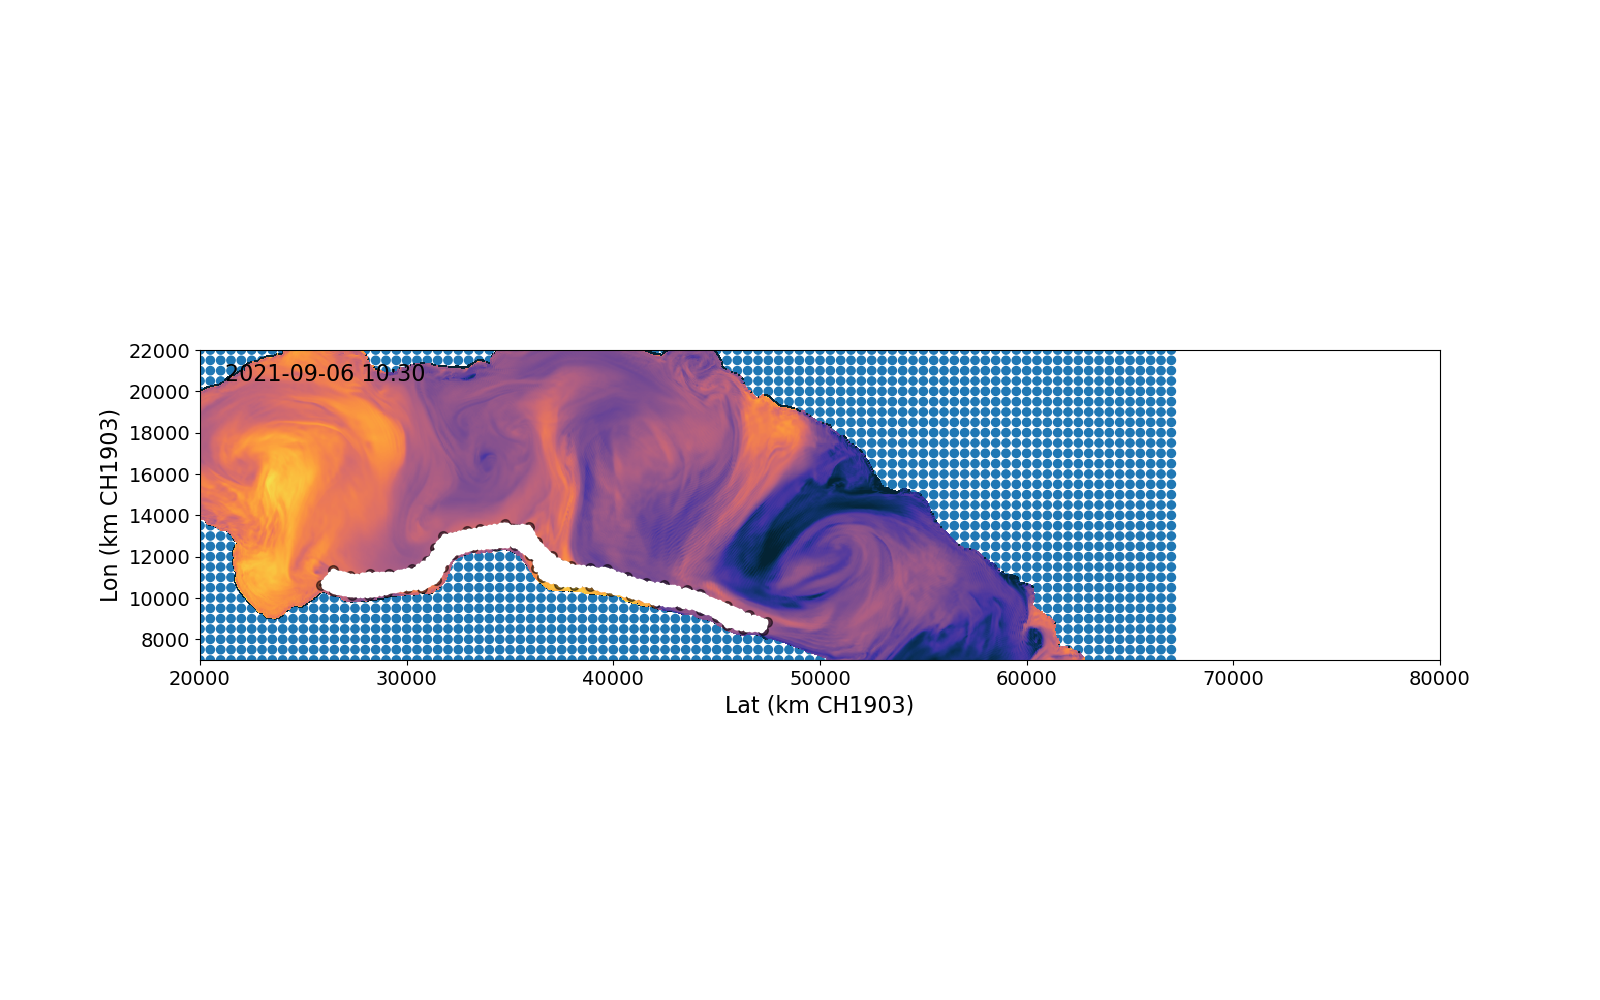

In [146]:
plt.hold = True
# plt.plot(*np.array(Polygon(selector.poly.verts)).T, 'g')
points_pt = random_points_within(Polygon(selector.poly.verts), 100)
coords = np.array([p.coords for p in points_pt]).reshape(-1, 2)
plt.plot(coords[:,0],coords[:,1], 'w.')

plt.show()

selector.disconnect()



In [147]:
np.where(coords[:,0] % 50==0)

(array([], dtype=int64),)

In [148]:
xx_seed = np.tile(coords[:,0], 4)
yy_seed = np.tile(coords[:,1], 4)
zz_seed = np.repeat([0.5,1,3,5], 100)

In [149]:
yy_seed.shape

(400,)

In [ ]:
np.savez(output_path+'PT13_100_4depths_1.npz', x_seed = xx_seed, y_seed = yy_seed, z_seed = zz_seed)

In [6]:
f = np.load(output_path+'PT13_100_4depths_1.npz')
for k, v in f.items():
        exec("{:s}=v.astype('float64')".format(k))

In [8]:
f['y_seed']

array([11141.62556317,  9762.25486761,  8558.00129475,  9903.33616171,
       11183.86674985,  9349.7115106 , 10536.40980751, 11242.34910706,
       10945.81518532, 10941.59960779, 10304.34453818, 11027.18286552,
        9000.72608722, 12584.70680352, 11034.77685138, 10428.45241128,
       11618.68972737, 10762.05825863, 10746.3880276 ,  8772.77753722,
       10872.7584566 , 11457.57026049, 10260.50354129, 10357.93158604,
       11419.83137389, 10351.49926412, 10462.64351798, 13535.29610941,
       10225.57851944, 10990.30971367, 10400.03466242,  9977.20557889,
       12626.20885337,  8845.04446664, 10675.52565797, 10884.17062513,
       10648.08307665, 10490.56630137,  9127.25644888, 12601.45062226,
        9937.37668814, 10819.35820929, 13242.20211421, 10710.11261124,
       10776.11656571, 12223.01986598, 12932.37567044, 10770.51410128,
       11293.07203775, 13355.21937612,  8657.34356498, 12666.24103835,
        8748.75261773, 10788.41676537, 10449.39151239, 13221.41682895,
      

In [64]:
f.files

['x_seed', 'y_seed', 'z_seed']

In [9]:
f.close()

In [9]:
output_path = 'G:/ALPLakes/algal_bloom_Sep2021/Particle_tracking/PT_secchi_low/PT13_forward_south/'
updated_output_path = 'G:/ALPLakes/algal_bloom_Sep2021/Particle_tracking/PT_secchi_low/PT14_forward_deepwater/'

In [21]:
f = np.load(output_path+'PT13_100_4depths_8.npz')
for k, v in f.items():
        exec("{:s}=v.astype('float64')".format(k))
        
xx_seed = np.tile(np.unique(f[f.files[0]]), 6)
yy_seed = np.tile(np.unique(f[f.files[1]]), 6)
zz_seed = np.repeat([20,30,40,50,80,120], len(np.unique(f[f.files[0]])))

np.savez(updated_output_path+'PT14_100_4depths_8.npz', x_seed = xx_seed, y_seed = yy_seed, z_seed = zz_seed)

In [138]:
(f[f.files[1]])

array([2684.27053673, 2663.9175591 , 2666.87687719, ..., 2685.57292366,
       2648.24291248, 2693.76063005])

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:18: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


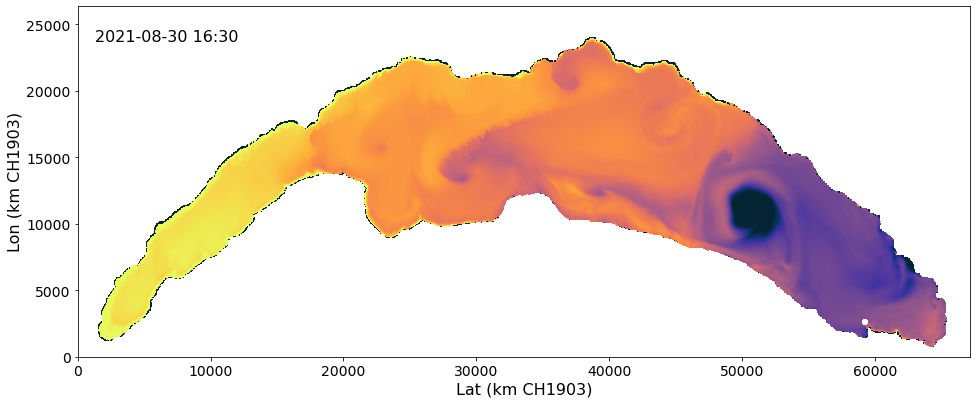

In [21]:
%matplotlib inline
font_feature = ['sans-serif', 16, 14] # [fontname, fontsize_labels, fontsize_ticks]

i=16
Temp = np.array(data.THETA[i, 0:3, :,:].mean(axis=0))
Temp[Temp <= 0] = np.nan
vort = np.array(data.momVort3[i, 0:1, :,:].mean(axis=0))
vort /= 1.05e-4

#####################
fig_size = (16,10)


f = plt.figure(figsize=fig_size)

ax = f.add_subplot(111)
# SS = plt.pcolormesh(xx_sg,yy_sg,Temp, cmap=cmocean.cm.thermal,shading='flat')
SS1 = plt.pcolormesh(xx_com,yy_com,Temp, cmap=cmocean.cm.thermal,vmin=np.nanpercentile(Temp.flatten(),2), vmax=np.nanpercentile(Temp.flatten(),98),shading='flat')
# SS2 = plt.pcolormesh(xx_com,yy_com,vort, vmin=-1.2, vmax=1.2,cmap=cmocean.cm.balance,shading='flat')

plt.hold=True
plt.plot(coords[:,0],coords[:,1], 'w.')

plt.xticks(fontname=font_feature[0],fontsize=font_feature[2])
plt.yticks(fontname=font_feature[0],fontsize=font_feature[2])

# ax.set_xlim(0, 65000)
# ax.set_ylim(0, 43000)
ax.set_aspect('equal')
ax.set_xlabel("Lat (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
ax.set_ylabel("Lon (km CH1903)",fontname=font_feature[0],fontsize=font_feature[1])
ax.annotate(date_obs[i].item().strftime("%Y-%m-%d %H:%M"),xy=(0.02, 0.9), xycoords='axes fraction',fontname=font_feature[0],fontsize=font_feature[1])

# cbar = plt.colorbar(fraction=0.04,orientation="horizontal",pad=-0.25,extend='max',format='%:.0f');
# cbar.ax.set_xticklabels(np.around(cbar.ax.get_xticks(), decimals=2),fontname=font_feature[0],fontsize=font_feature[2])
# cbar.set_label(label='$\mathregular{Surface \ temperature \ [^{o}C]}$',family=font_feature[0],size=font_feature[1])
# cbar.ax.xaxis.set_ticks_position('top')

# plt.savefig(output_path+'PT5_150000_3depths.png',dpi=300, bbox_inches = 'tight')

plt.show()
plt.close()
